# Anotación de DEGs de lubina — Pipeline completo
## TFM — Biomarcadores transcriptómicos de eficiencia digestiva en dorada y lubina
### Autor: Ángel López Francés | Universidad de Murcia

---
## Objetivo de este notebook

El microarray usado en GSE59240 (Calduch-Giner et al., 2016) es un **array personalizado Agilent** (GPL18910) construido con la base de datos SeaBassDB del IATS-CSIC. Sus sondas tienen IDs internos (`L3_83747`, `L12_34593`...) que no son nombres de genes directamente.Por tanto cruzamos los DEGs con el archivo de anotación de la plataforma GPL18910 para obtener las secuencias de cada sonda y generamos FASTA para hacer BLAST en NCBI y obtener los nombres de genes; y con los resultados de BLAST (formato Hit Table) obtenemos los accession numbers de RefSeq asociados a cada sonda del microarray.

**SOFT + Patrones + FASTA** 
- Extrae la anotación del SOFT GPL18910
- Calcula los patrones ANT-MED / POS
- Genera archivos FASTA para NCBI BLAST

**Procesar HitTable BLAST** 
- Filtra y procesa el HitTable descargado de NCBI BLAST
- Cruza con accessions de Batch Entrez
- Exporta lista de accessions

**Genes nuevos vs paper** 
- Identifica genes no descritos en Calduch-Giner et al. (2016)
- Genera figuras y tabla para el TFM

**Archivos de entrada:**
- `GPL18910_family.soft` — plataforma del microarray
- `DEGs_lubina_intestino.csv` — output de `NB2_Lubina_Pipeline.ipynb`
- `Z9HMPAJW014-Alignment-HitTable.csv` — HitTable de NCBI BLAST
- `nuccore_result.txt` — resultado de NCBI Batch Entrez

**Archivos de salida:**
- `DEGs_lubina_anotados.csv`
- `BLAST_lubina_AltoANT-MED.fasta`
- `DEGs_lubina_con_accession.csv`
- `accessions_lubina.txt`
- `tabla_genes_nuevos_lubina.csv`
- `Fig1_genes_nuevos_lubina.png`

**Referencia:**
Calduch-Giner, J. A., Sitjà-Bobadilla, A., & Pérez-Sánchez, J. (2016). Gene expression profiling reveals functional specialization along the intestinal tract of a carnivorous teleostean fish (*Dicentrarchus labrax*). *Frontiers in Physiology, 7*, 359. https://doi.org/10.3389/fphys.2016.00359

## Extracción del SOFT y clasificación de patrones

### 1.1 Importación de librerías


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import io
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')

print(' Librerías importadas correctamente')

 Librerías importadas correctamente


### 1.2 Extracción de la tabla de anotación del SOFT (GPL18910)
El archivo SOFT de la plataforma GPL18910 contiene la tabla de anotación del microarray.
Tiene formato específico de GEO con marcadores `!platform_table_begin` y `!platform_table_end`.

Las columnas relevantes son:
- `ACCESSION_STRING` → ID de sonda que coincide con nuestros GeneIDs (ej: `L12_14278`)
- `SEQUENCE` → secuencia nucleotídica de la sonda (60 bp) para hacer BLAST

In [3]:
ruta_soft = 'c:\\Users\\angel\\Desktop\\datos tfm\\GPL18910_family.soft'

with open(ruta_soft, 'r', errors='replace') as f:
    lines = f.readlines()

# Localizar inicio y fin de la tabla de anotación
start, end = None, None
for i, line in enumerate(lines):
    if '!platform_table_begin' in line.lower():
        start = i + 1  # La tabla comienza en la siguiente línea
    if '!platform_table_end' in line.lower():
        end = i
        break

print(f'Tabla de plataforma encontrada: líneas {start} a {end}')
print(f'Total de sondas: {end - start - 1:,}')

# Parsear la tabla como DataFrame
tabla_str = ''.join(lines[start:end])
anotacion = pd.read_csv(io.StringIO(tabla_str), sep='\t')

# Crear columna GeneID que coincide con los IDs de nuestros DEGs
anotacion['GeneID'] = anotacion['ACCESSION_STRING']

print(f'\nColumnas disponibles: {anotacion.columns.tolist()}')
print(f'\nPrimeras filas:')
anotacion[['GeneID', 'SEQUENCE']].head(5)

Tabla de plataforma encontrada: líneas 72 a 14280
Total de sondas: 14,207

Columnas disponibles: ['ID', 'SPOT_ID', 'CONTROL_TYPE', 'ACCESSION_STRING', 'CHROMOSOMAL_LOCATION', 'SEQUENCE', 'GeneID']

Primeras filas:


,GeneID,SEQUENCE
0,L12_14278,AGGGAGGAGAGGGCAACAACTAAAGAGTCCAAAACCTCATTCTGCC...
1,L12_15072,GTTCAGAGTGAACGGGTTCCTGTTAGCGGCGCTGGCCGTTATAGGT...
2,L12_15957,TTAAAGCAAAGGAAAGAAGAGATGATCCAGCAGGCACGCAGGAGAT...
3,L12_17496,AGTTTGTCGAGGTTGTCGATAACGACTTTACCGATGAAAGCATGTA...
4,L12_17782,TCCAACTGGTTGACCTACAAGAGATTTCCATTCCTAGTGCCAAAGC...


### 1.3 Cargar DEGs de lubina
Cargamos el archivo generado en el notebook `TFM_Lubina_Microarray.ipynb` con los genes diferencialmente expresados entre los tres segmentos intestinales.

In [4]:
# Cargar DEGs
degs = pd.read_csv('C:\\Users\\angel\\Desktop\\blast y anotacion completa\\tablasygraficasyjupiters\\DEGs_lubina_intestino.csv', index_col=0)

# Calcular fold changes entre segmentos (en escala log2)
# FC positivo = mayor en ANT que en POS
degs['FC_ANT_vs_POS'] = degs['media_ANT'] - degs['media_POS']
degs['FC_MED_vs_POS'] = degs['media_MED'] - degs['media_POS']
degs['FC_ANT_vs_MED'] = degs['media_ANT'] - degs['media_MED']

print(f'DEGs totales (FDR<0.05): {len(degs):,}')
print(f'DEGs FDR<0.01: {(degs["padj"]<0.01).sum():,}')
print(f'DEGs FDR<0.001: {(degs["padj"]<0.001).sum():,}')
print(f'\nColumnas: {degs.columns.tolist()}')
degs.head()

DEGs totales (FDR<0.05): 4,613
DEGs FDR<0.01: 2,965
DEGs FDR<0.001: 1,635

Columnas: ['pvalue', 'padj', 'media_ANT', 'media_MED', 'media_POS', 'FC_ANT_vs_POS', 'FC_MED_vs_POS', 'FC_ANT_vs_MED']


,pvalue,padj,media_ANT,media_MED,media_POS,FC_ANT_vs_POS,FC_MED_vs_POS,FC_ANT_vs_MED
GeneID,,,,,,,,
L3_83747,2.161623e-18,2.903515e-14,18.376787,18.373001,13.274004,5.102783,5.098997,0.003786
L2_28353,4.104778e-18,2.903515e-14,10.733166,10.727529,4.588352,6.144814,6.139177,0.005637
L12_34593,2.919123e-17,1.376561e-13,18.862050,18.858677,9.316545,9.545505,9.542132,0.003373
L12_84939,1.755821e-16,6.209901e-13,13.512638,13.367796,18.396969,-4.884331,-5.029173,0.144842
L12_89941,3.116161e-16,8.816866e-13,14.827564,14.611801,7.976256,6.851308,6.635545,0.215763


### 1.4 Clasificación por patrón de expresión (ANT-MED / POS / Uniforme)

Distribución de patrones de expresión:
  Uniforme       : 3014 genes (65.3%)
  Alto_ANT-MED   :  834 genes (18.1%)
  Alto_POS       :  747 genes (16.2%)
  Alto_MED       :   11 genes (0.2%)
  Alto_ANT       :    7 genes (0.2%)


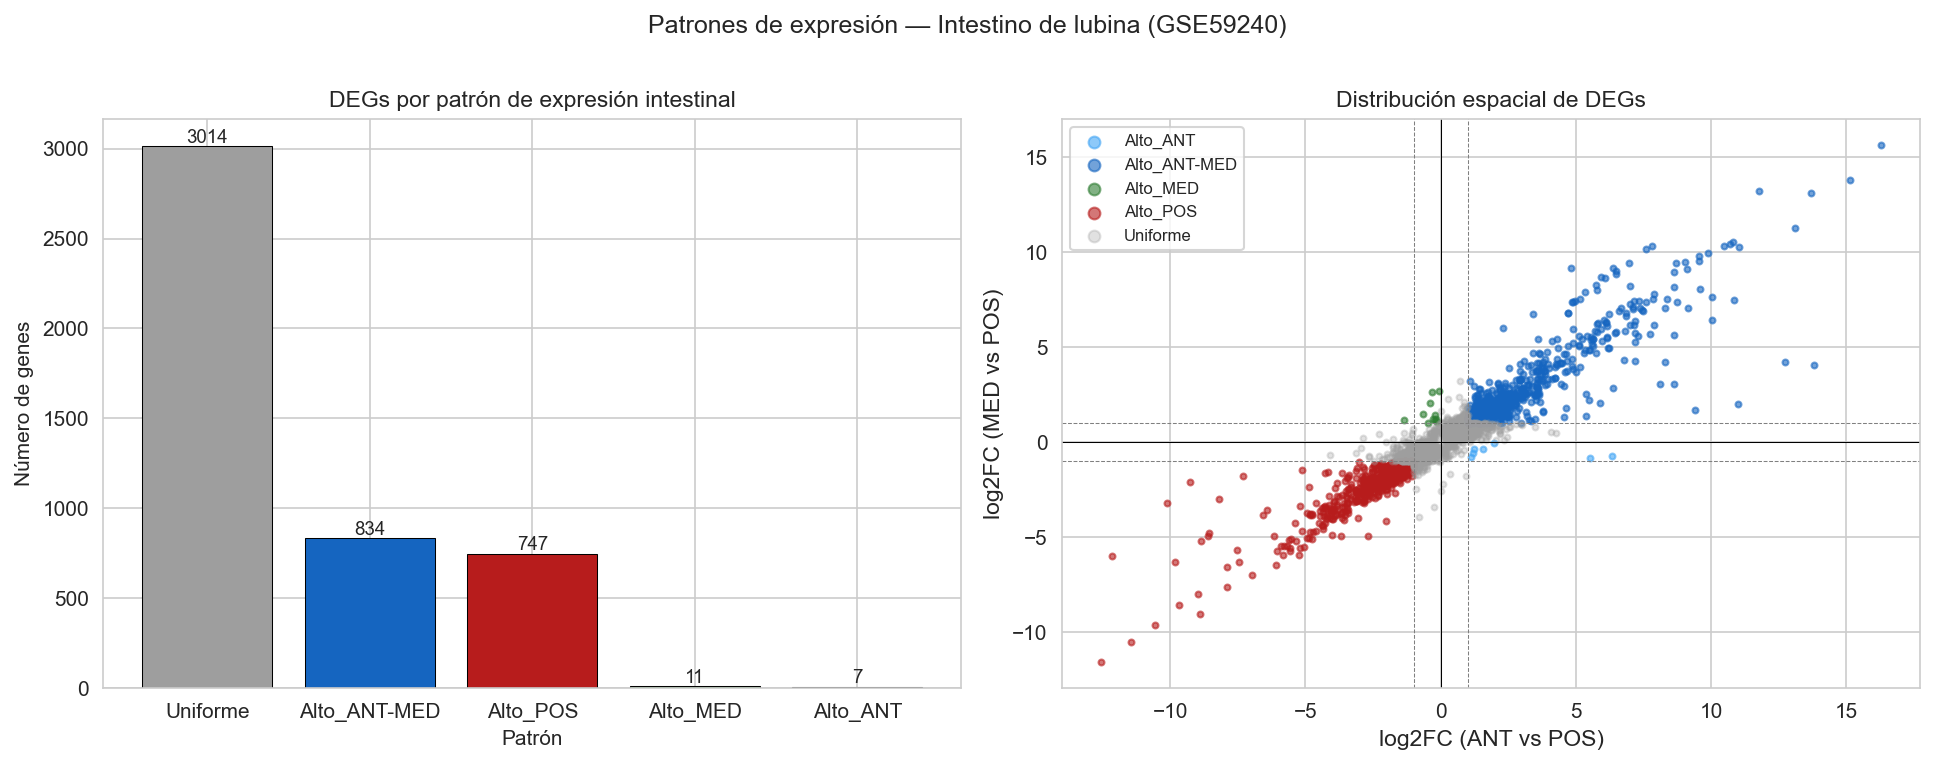

Figura guardada: Patrones_expresion_lubina.png


In [6]:
# Clasificar patrones de expresión
# Umbral de |log2FC| > 1 = cambio de al menos 2 veces
UMBRAL_FC = 1.0

def clasificar_patron(row):
    fc_ant_pos = row['FC_ANT_vs_POS']
    fc_med_pos = row['FC_MED_vs_POS']
    
    if fc_ant_pos > UMBRAL_FC and fc_med_pos > UMBRAL_FC:
        return 'Alto_ANT-MED'   # alto en anterior y medio
    elif fc_ant_pos < -UMBRAL_FC and fc_med_pos < -UMBRAL_FC:
        return 'Alto_POS'       # alto en posterior
    elif fc_ant_pos > UMBRAL_FC and fc_med_pos < 0:
        return 'Alto_ANT'       # gradiente decreciente ANT→POS
    elif fc_ant_pos < 0 and fc_med_pos > UMBRAL_FC:
        return 'Alto_MED'       # pico en medio
    else:
        return 'Uniforme'

degs['Patron'] = degs.apply(clasificar_patron, axis=1)

# Resumen
conteos = degs['Patron'].value_counts()
print('Distribución de patrones de expresión:')
for patron, n in conteos.items():
    pct = n/len(degs)*100
    print(f'  {patron:15s}: {n:4d} genes ({pct:.1f}%)')

# Gráfico de distribución
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores_patron = {
    'Alto_ANT-MED': '#1565C0',
    'Alto_POS':     '#B71C1C',
    'Alto_ANT':     '#42A5F5',
    'Alto_MED':     '#2E7D32',
    'Uniforme':     '#9E9E9E'
}

# Gráfico de barras
colores_barras = [colores_patron.get(p, '#9E9E9E') for p in conteos.index]
axes[0].bar(conteos.index, conteos.values, color=colores_barras,
            edgecolor='black', linewidth=0.5)
axes[0].set_title('DEGs por patrón de expresión intestinal', fontsize=11)
axes[0].set_ylabel('Número de genes')
axes[0].set_xlabel('Patrón')
for i, (p, n) in enumerate(conteos.items()):
    axes[0].text(i, n + 20, str(n), ha='center', fontsize=9)

# Scatter FC_ANT_vs_POS vs FC_MED_vs_POS
for patron, datos_p in degs.groupby('Patron'):
    color = colores_patron.get(patron, '#9E9E9E')
    alpha = 0.3 if patron == 'Uniforme' else 0.6
    axes[1].scatter(datos_p['FC_ANT_vs_POS'], datos_p['FC_MED_vs_POS'],
                    c=color, s=8, alpha=alpha, label=patron, rasterized=True)

axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].axhline(UMBRAL_FC, color='gray', linewidth=0.5, linestyle='--')
axes[1].axhline(-UMBRAL_FC, color='gray', linewidth=0.5, linestyle='--')
axes[1].axvline(UMBRAL_FC, color='gray', linewidth=0.5, linestyle='--')
axes[1].axvline(-UMBRAL_FC, color='gray', linewidth=0.5, linestyle='--')
axes[1].set_xlabel('log2FC (ANT vs POS)', fontsize=11)
axes[1].set_ylabel('log2FC (MED vs POS)', fontsize=11)
axes[1].set_title('Distribución espacial de DEGs', fontsize=11)
axes[1].legend(markerscale=2, fontsize=8)

plt.suptitle('Patrones de expresión — Intestino de lubina (GSE59240)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('Patrones_expresion_lubina.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura guardada: Patrones_expresion_lubina.png')

### 1.5 Cruzar DEGs con secuencias del array
Cruzamos los DEGs con la tabla de anotación del SOFT para añadir las secuencias de cada sonda.
Estas secuencias son las que usaremos en el paso siguiente para identificar los genes mediante BLAST.

In [7]:
# Cruzar DEGs con secuencias del array
degs_anotados = degs.merge(
    anotacion[['GeneID', 'SEQUENCE']],
    left_index=True,
    right_on='GeneID',
    how='left'
).set_index('GeneID')

cobertura = degs_anotados['SEQUENCE'].notna().sum()
print(f'DEGs con secuencia asignada: {cobertura}/{len(degs_anotados)} ({cobertura/len(degs_anotados)*100:.1f}%)')
print(f'\nTabla final:')
degs_anotados[['padj', 'media_ANT', 'media_MED', 'media_POS',
               'FC_ANT_vs_POS', 'FC_MED_vs_POS', 'Patron', 'SEQUENCE']].head(10)

DEGs con secuencia asignada: 4613/4613 (100.0%)

Tabla final:


,padj,media_ANT,media_MED,media_POS,FC_ANT_vs_POS,FC_MED_vs_POS,Patron,SEQUENCE
GeneID,,,,,,,,
L3_83747,2.903515e-14,18.376787,18.373001,13.274004,5.102783,5.098997,Alto_ANT-MED,CCACAACAATGTCATCAAGACCCTGAAGGAAAAAAGTAAAAATGTT...
L2_28353,2.903515e-14,10.733166,10.727529,4.588352,6.144814,6.139177,Alto_ANT-MED,AGCAAATGTCAGAGGCAAGCCAGATGCTGTTGGGATGATGAATTCG...
L12_34593,1.376561e-13,18.862050,18.858677,9.316545,9.545505,9.542132,Alto_ANT-MED,TACTTCGAGGAGATGAAGAACAAAATGACCCAGGACCTGACTGAGA...
L12_84939,6.209901e-13,13.512638,13.367796,18.396969,-4.884331,-5.029173,Alto_POS,GATGAATAGTACTGTATTCTGTATTGGTTCTAAGCGTGCGTGATTG...
L12_89941,8.816866e-13,14.827564,14.611801,7.976256,6.851308,6.635545,Alto_ANT-MED,GAATGTTTTCACCACCCAAATCGAGATACCTGACTTTGATGTTGAG...
L12_83830,1.420014e-12,10.798395,10.804590,16.361315,-5.562920,-5.556725,Alto_POS,GTCGGTGATTTCAAGATTAAGGCAGCTCAAAAGATCACCATCAAAA...
L12_88586,1.488748e-12,6.398986,6.521717,10.489650,-4.090664,-3.967933,Alto_POS,TTCCCAGTATACAAGTATGTCCCATATGGCCCTGTCAACGAGGTGA...
L12_84913,2.196596e-12,11.194633,11.154753,5.635489,5.559144,5.519264,Alto_ANT-MED,GTAAAACCGTTATGTTGACTTCGACAGTGGCTTTTTGTATTTTACG...
L12_85179,4.064441e-12,14.427741,14.483564,8.658461,5.769280,5.825103,Alto_ANT-MED,CCTCTCTTTGTTTGATGCTCTTTGGAATCTGTTGAGGTTAATAAAC...


### 1.6 Exportar tabla DEGs anotados con secuencias

In [8]:
# Guardar tabla completa con todos los campos
columnas_exportar = [
    'pvalue', 'padj',
    'media_ANT', 'media_MED', 'media_POS',
    'FC_ANT_vs_POS', 'FC_MED_vs_POS', 'FC_ANT_vs_MED',
    'Patron', 'SEQUENCE'
]
degs_anotados[columnas_exportar].sort_values('padj').to_csv('DEGs_lubina_anotados.csv')

print(' Tabla guardada: DEGs_lubina_anotados.csv')
print(f'   Total DEGs: {len(degs_anotados):,}')
print(f'   Con secuencia: {degs_anotados["SEQUENCE"].notna().sum():,}')
print(f'\nDistribución por patrón:')
for patron, grp in degs_anotados.groupby('Patron'):
    print(f'   {patron:15s}: {len(grp):4d} genes')

 Tabla guardada: DEGs_lubina_anotados.csv
   Total DEGs: 4,613
   Con secuencia: 4,613

Distribución por patrón:
   Alto_ANT       :    7 genes
   Alto_ANT-MED   :  834 genes
   Alto_MED       :   11 genes
   Alto_POS       :  747 genes
   Uniforme       : 3014 genes


### 1.7 Generar archivos FASTA para BLAST

El array GPL18910 es personalizado y no tiene nombres de genes en su anotación, solo secuencias de sondas de 60 pb. Usando BLAST podemos comparar estas secuencias contra bases de datos de  nucleótidos (RefSeq) para obtener el nombre del gen y su función.

In [9]:
def generar_fasta(df, patron_filtro, n_top, nombre_archivo, etiqueta):
    """
    Genera un archivo FASTA con las secuencias de los top N DEGs
    de un patrón de expresión dado.
    
    """
    if isinstance(patron_filtro, list):
        subset = df[df['Patron'].isin(patron_filtro)]
    else:
        subset = df[df['Patron'] == patron_filtro]
    
    top = subset.dropna(subset=['SEQUENCE']).nsmallest(n_top, 'padj')
    
    fasta_lines = []
    for gid, row in top.iterrows():
        header = (f">{gid}|{etiqueta}"
                  f"|FC_ANT_POS={row['FC_ANT_vs_POS']:.2f}"
                  f"|FDR={row['padj']:.2e}")
        fasta_lines.append(header)
        fasta_lines.append(str(row['SEQUENCE']))
    
    with open(nombre_archivo, 'w') as f:
        f.write('\n'.join(fasta_lines))
    
    print(f' {nombre_archivo} — {len(top)} secuencias')
    return top

# FASTA 1: Genes alto en ANT-MED (digestión y absorción)
top_ant_med = generar_fasta(
    degs_anotados, 'Alto_ANT-MED', 100,
    'BLAST_lubina_AltoANT-MED.fasta',
    'AltoANT-MED_digestion-absorcion'
)

# FASTA 2: Genes alto en POS (transporte iónico, inmunidad)
top_pos = generar_fasta(
    degs_anotados, 'Alto_POS', 100,
    'BLAST_lubina_AltoPOS.fasta',
    'AltoPOS_transporte-ionico-inmunidad'
)

# FASTA 3: Top 50 DEGs más significativos (independiente del patrón)
top_general = generar_fasta(
    degs_anotados, list(degs_anotados['Patron'].unique()), 50,
    'BLAST_lubina_Top50_general.fasta',
    'Top50_MasSignificativos'
)
print('Archivos FASTA generados para BLAST.')

 BLAST_lubina_AltoANT-MED.fasta — 100 secuencias
 BLAST_lubina_AltoPOS.fasta — 100 secuencias
 BLAST_lubina_Top50_general.fasta — 50 secuencias
Archivos FASTA generados para BLAST.


### 1.8 Heatmap por patrón de expresión

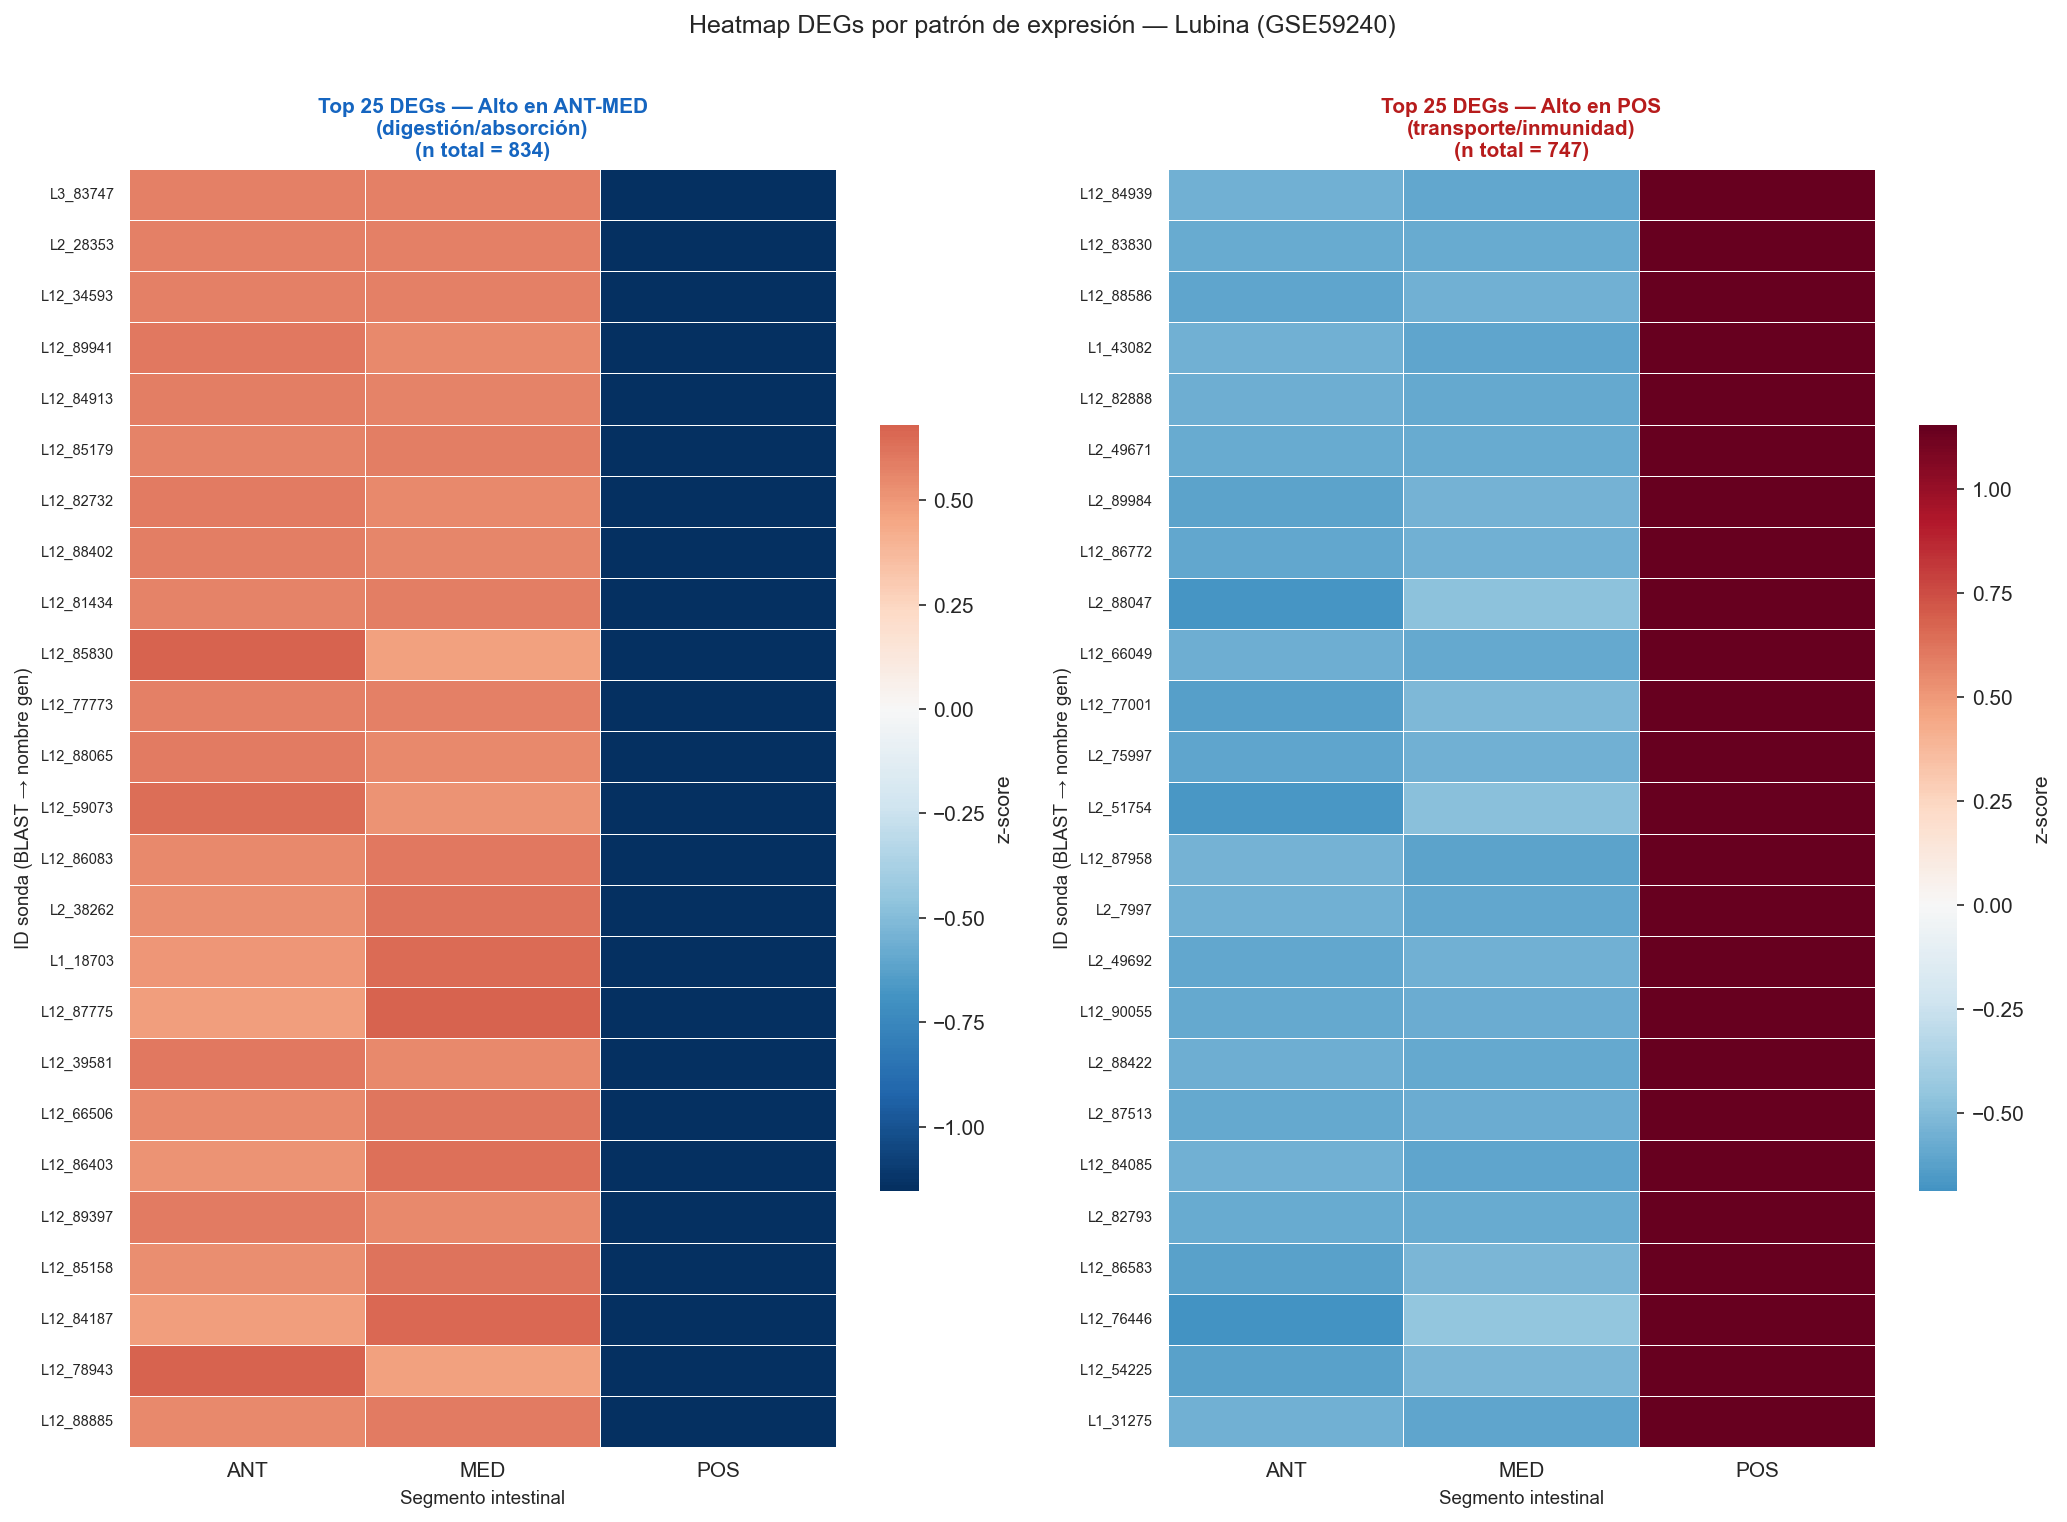

Figura guardada: Heatmap_patrones_lubina.png


In [10]:
# Heatmap de los top DEGs de cada patrón biológicamente relevante
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

for ax, (patron, titulo, color_barra) in zip(
    axes,
    [
        ('Alto_ANT-MED', 'Alto en ANT-MED\n(digestión/absorción)', '#1565C0'),
        ('Alto_POS',     'Alto en POS\n(transporte/inmunidad)',   '#B71C1C'),
    ]
):
    subset = degs_anotados[degs_anotados['Patron'] == patron].nsmallest(25, 'padj')
    
    # Matriz de medias por segmento
    heatmap_data = subset[['media_ANT', 'media_MED', 'media_POS']].copy()
    heatmap_data.columns = ['ANT', 'MED', 'POS']
    
    # Estandarizar por fila
    heatmap_z = heatmap_data.subtract(heatmap_data.mean(axis=1), axis=0)
    heatmap_z = heatmap_z.divide(heatmap_data.std(axis=1), axis=0)
    
    sns.heatmap(
        heatmap_z,
        ax=ax,
        cmap='RdBu_r',
        center=0,
        yticklabels=True,
        xticklabels=True,
        linewidths=0.3,
        linecolor='white',
        cbar_kws={'label': 'z-score', 'shrink': 0.6}
    )
    ax.set_title(f'Top 25 DEGs — {titulo}\n(n total = {(degs_anotados["Patron"]==patron).sum()})',
                 fontsize=10, color=color_barra, fontweight='bold')
    ax.set_ylabel('ID sonda (BLAST → nombre gen)', fontsize=9)
    ax.set_xlabel('Segmento intestinal', fontsize=9)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Heatmap DEGs por patrón de expresión — Lubina (GSE59240)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('Heatmap_patrones_lubina.png', bbox_inches='tight', dpi=200)
plt.show()
print('Figura guardada: Heatmap_patrones_lubina.png')

## Procesar HitTable de BLAST



### 2.1 Cargar HitTable de BLAST

**Criterios de calidad del hit:**
- % identidad ≥ 95%
- E-value < 1e-10
- Para hits múltiples por gen: se conserva el de mayor identidad y menor e-value

### 2.2 Parseo del campo query y control de calidad

In [11]:
# Leer HitTable
blast_raw = pd.read_csv('C:\\Users\\angel\\Desktop\\blast y anotacion completa\\subir\\lubina\\Z9HMPAJW014-Alignment-HitTable.csv', header=None,
    names=['query_full','subject_acc','pct_identity','alignment_length',
           'mismatches','gap_opens','q_start','q_end','s_start','s_end',
           'evalue','bit_score'])

print(f'Total de hits BLAST: {len(blast_raw):,}')
print(f'Columnas: {blast_raw.columns.tolist()}')
print(f'\nPrimeras filas:')
blast_raw.head()

Total de hits BLAST: 174
Columnas: ['query_full', 'subject_acc', 'pct_identity', 'alignment_length', 'mismatches', 'gap_opens', 'q_start', 'q_end', 's_start', 's_end', 'evalue', 'bit_score']

Primeras filas:


,query_full,subject_acc,pct_identity,alignment_length,mismatches,gap_opens,q_start,q_end,s_start,s_end,evalue,bit_score
0,L3_83747|AltoANT-MED_digestion-absorcion|FC_AN...,XR_007885885.1,100.000,60,0,0,1,60,9886,9945,1.790000e-24,111.0
1,L2_28353|AltoANT-MED_digestion-absorcion|FC_AN...,XR_007885885.1,98.333,60,1,0,1,60,2587,2528,8.310000e-23,106.0
2,L12_34593|AltoANT-MED_digestion-absorcion|FC_A...,XM_051390030.1,98.333,60,1,0,1,60,213,272,8.310000e-23,106.0
3,L12_89941|AltoANT-MED_digestion-absorcion|FC_A...,XR_007885885.1,100.000,60,0,0,1,60,3190,3249,1.790000e-24,111.0
4,L12_84913|AltoANT-MED_digestion-absorcion|FC_A...,XM_051411637.1,100.000,30,0,0,1,30,1613,1642,8.490000e-08,56.5


### 2.3 Filtrado y selección del mejor hit por gen

Genes únicos en BLAST: 94
% identidad media: 99.5%
Rango e-value: 1.79e-24 — 3.05e-07


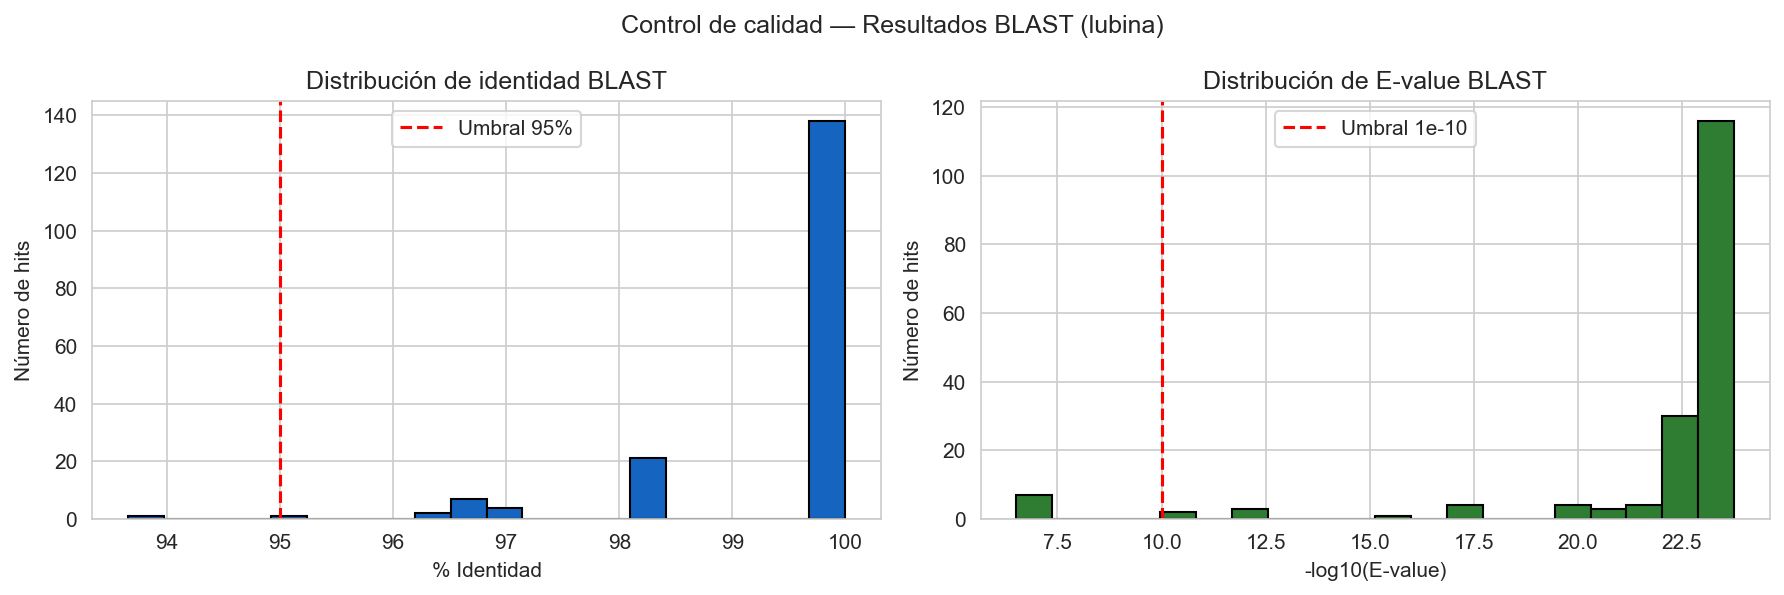

Figura guardada: QC_BLAST_lubina.png


In [12]:
# Extraer campos del query_full

blast_raw['GeneID']     = blast_raw['query_full'].str.split('|').str[0]
blast_raw['Patron']     = blast_raw['query_full'].str.split('|').str[1]
blast_raw['FC_ANT_POS'] = blast_raw['query_full'].str.extract(r'FC_ANT_POS=([0-9.\-]+)').astype(float)
blast_raw['FDR']        = blast_raw['query_full'].str.extract(r'FDR=([0-9.e\-]+)').astype(float)

print(f'Genes únicos en BLAST: {blast_raw["GeneID"].nunique()}')
print(f'% identidad media: {blast_raw["pct_identity"].mean():.1f}%')
print(f'Rango e-value: {blast_raw["evalue"].min():.2e} — {blast_raw["evalue"].max():.2e}')

# Distribución de identidades
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(blast_raw['pct_identity'], bins=20, color='#1565C0', edgecolor='black')
axes[0].set_xlabel('% Identidad')
axes[0].set_ylabel('Número de hits')
axes[0].set_title('Distribución de identidad BLAST')
axes[0].axvline(95, color='red', linestyle='--', label='Umbral 95%')
axes[0].legend()

axes[1].hist(-np.log10(blast_raw['evalue'] + 1e-30), bins=20, color='#2E7D32', edgecolor='black')
axes[1].set_xlabel('-log10(E-value)')
axes[1].set_ylabel('Número de hits')
axes[1].set_title('Distribución de E-value BLAST')
axes[1].axvline(10, color='red', linestyle='--', label='Umbral 1e-10')
axes[1].legend()

plt.suptitle('Control de calidad — Resultados BLAST (lubina)', fontsize=12)
plt.tight_layout()
plt.savefig('QC_BLAST_lubina.png', bbox_inches='tight')
plt.show()
print('Figura guardada: QC_BLAST_lubina.png')

### 2.4 Cruzar con DEGs de lubina

In [13]:
# Filtrar por calidad
UMBRAL_IDENTIDAD = 90   # % mínimo de identidad
UMBRAL_EVALUE    = 1e-5 # e-value máximo

blast_filtrado = blast_raw[
    (blast_raw['pct_identity'] >= UMBRAL_IDENTIDAD) &
    (blast_raw['evalue'] <= UMBRAL_EVALUE)
].copy()

print(f'Hits antes del filtrado:  {len(blast_raw):,}')
print(f'Hits después del filtrado: {len(blast_filtrado):,}')

# Seleccionamos el MEJOR hit por gen
blast_best = (
    blast_filtrado
    .sort_values(['GeneID', 'pct_identity', 'evalue'],
                  ascending=[True, False, True])
    .drop_duplicates('GeneID', keep='first')
)

print(f'\nGenes con hit de calidad: {len(blast_best):,}')
print(f'Identidad media (mejores hits): {blast_best["pct_identity"].mean():.2f}%')
print(f'\nTop 10 hits más significativos:')
blast_best.nsmallest(10, 'evalue')[['GeneID','subject_acc','pct_identity',
                                     'evalue','FC_ANT_POS','FDR']]

Hits antes del filtrado:  174
Hits después del filtrado: 174

Genes con hit de calidad: 94
Identidad media (mejores hits): 99.54%

Top 10 hits más significativos:


,GeneID,subject_acc,pct_identity,evalue,FC_ANT_POS,FDR
24,L12_39581,XM_051386316.1,100.0,1.790000e-24,4.28,4.730000e-11
19,L12_59073,XM_051407222.1,100.0,1.790000e-24,11.05,2.030000e-11
113,L12_59925,XM_051378720.1,100.0,1.790000e-24,3.36,3.710000e-08
153,L12_64530,XM_051396035.1,100.0,1.790000e-24,1.64,8.870000e-08
25,L12_66506,XM_051413564.1,100.0,1.790000e-24,8.65,6.670000e-11
54,L12_72937,XM_051390817.1,100.0,1.790000e-24,4.43,4.250000e-10
67,L12_73756,XM_051384715.1,100.0,1.790000e-24,4.86,3.790000e-09
48,L12_73826,XM_051420001.1,100.0,1.790000e-24,4.68,3.600000e-10
53,L12_75419,XM_051402336.1,100.0,1.790000e-24,3.54,3.880000e-10
162,L12_76473,XM_051427274.1,100.0,1.790000e-24,2.24,1.420000e-07


### 2.5 Tabla de genes anotados por patrón

In [14]:
# Cargar DEGs anotados (del notebook anterior)
degs = pd.read_csv('C:\\Users\\angel\\Desktop\\blast y anotacion completa\\subir\\lubina\\DEGs_lubina_anotados.csv', index_col=0)

print(f'DEGs cargados: {len(degs):,}')
print(f'Columnas: {degs.columns.tolist()}')

# Cruzar DEGs con resultados BLAST
degs_anotados = degs.merge(
    blast_best[['GeneID', 'subject_acc', 'pct_identity', 'evalue', 'bit_score']],
    left_index=True,
    right_on='GeneID',
    how='left'
).set_index('GeneID')

n_anotados  = degs_anotados['subject_acc'].notna().sum()
n_sin_anotar = degs_anotados['subject_acc'].isna().sum()

print(f'\n Resultado del cruce:')
print(f'   DEGs con accession BLAST: {n_anotados} ({n_anotados/len(degs_anotados)*100:.1f}%)')
print(f'   DEGs sin anotar:          {n_sin_anotar} ({n_sin_anotar/len(degs_anotados)*100:.1f}%)')

DEGs cargados: 4,613
Columnas: ['pvalue', 'padj', 'media_ANT', 'media_MED', 'media_POS', 'FC_ANT_vs_POS', 'FC_MED_vs_POS', 'FC_ANT_vs_MED', 'Patron', 'SEQUENCE']

 Resultado del cruce:
   DEGs con accession BLAST: 94 (2.0%)
   DEGs sin anotar:          4519 (98.0%)


### 2.6 Exportar tabla y lista de accessions para Batch Entrez

In [15]:
# Ver genes anotados por patrón
cols_mostrar = ['padj', 'FC_ANT_vs_POS', 'FC_MED_vs_POS', 'Patron',
                'subject_acc', 'pct_identity', 'evalue']

print('GENES ALTO EN ANT-MED (digestión y absorción) ')
ant_med = degs_anotados[
    (degs_anotados['Patron'] == 'Alto_ANT-MED') &
    (degs_anotados['subject_acc'].notna())
].sort_values('padj')
print(f'Total: {len(ant_med)}')
print(ant_med[cols_mostrar].head(20).to_string())



GENES ALTO EN ANT-MED (digestión y absorción) 
Total: 94
                   padj  FC_ANT_vs_POS  FC_MED_vs_POS        Patron     subject_acc  pct_identity        evalue
GeneID                                                                                                         
L3_83747   2.903515e-14       5.102783       5.098997  Alto_ANT-MED  XR_007885885.1       100.000  1.790000e-24
L2_28353   2.903515e-14       6.144814       6.139177  Alto_ANT-MED  XR_007885885.1        98.333  8.310000e-23
L12_34593  1.376561e-13       9.545505       9.542132  Alto_ANT-MED  XM_051390030.1        98.333  8.310000e-23
L12_89941  8.816866e-13       6.851308       6.635545  Alto_ANT-MED  XR_007885885.1       100.000  1.790000e-24
L12_84913  2.196596e-12       5.559144       5.519264  Alto_ANT-MED  XM_051411637.1       100.000  8.490000e-08
L12_85179  4.064441e-12       5.769280       5.825103  Alto_ANT-MED  XM_051426087.1       100.000  2.310000e-23
L12_81434  5.256850e-12       7.328828       7.

In [16]:
# Exportar tabla completa con accessions
columnas_exportar = [
    'pvalue', 'padj',
    'media_ANT', 'media_MED', 'media_POS',
    'FC_ANT_vs_POS', 'FC_MED_vs_POS', 'FC_ANT_vs_MED',
    'Patron',
    'subject_acc', 'pct_identity', 'evalue', 'bit_score'
]

# Solo columnas que existen
cols_ok = [c for c in columnas_exportar if c in degs_anotados.columns]
tabla_final = degs_anotados[cols_ok].sort_values('padj')
tabla_final.to_csv('DEGs_lubina_con_accession.csv')

# Exportar solo los anotados para la comparativa con dorada
tabla_anotados = tabla_final[tabla_final['subject_acc'].notna()]
tabla_anotados.to_csv('DEGs_lubina_anotados_BLAST.csv')

print('Archivos exportados:')
print(f'   DEGs_lubina_con_accession.csv    — {len(tabla_final):,} DEGs (todos)')
print(f'   DEGs_lubina_anotados_BLAST.csv   — {len(tabla_anotados):,} DEGs (solo con accession)')
print(f'\nDistribución de anotados por patrón:')
print(tabla_anotados.groupby('Patron').size().to_string())

Archivos exportados:
   DEGs_lubina_con_accession.csv    — 4,613 DEGs (todos)
   DEGs_lubina_anotados_BLAST.csv   — 94 DEGs (solo con accession)

Distribución de anotados por patrón:
Patron
Alto_ANT-MED    94


### 2.7 Cómo obtener los nombres de genes

Los accession numbers tipo `XM_051390030.1` son transcriptos de RefSeq de *D. labrax*.
Para obtener el nombre del gen hay dos métodos pero usamos:

### Método — Batch Entrez 
1. En https://www.ncbi.nlm.nih.gov/sites/batchentrez
2. Con la base de datos: **Nucleotide**
3. Subimos nuestro archivo `accessions_lubina.txt` generado 
4. Descargamos en formato **Summary** 


## Identificación de genes nuevos respecto al paper original

### 3.1 Parsear Batch Entrez (nuccore_result.txt)

In [28]:
import re
def parsear_nuccore_txt(ruta):

    with open(ruta, 'r', encoding='utf-8', errors='replace') as f:
        texto = f.read()

    # Dividir por entradas numeradas (1. , 2. , 3. ...)
    entradas = re.split(r'\n\d+\.\s+', texto)

    genes = []
    for entrada in entradas:
        entrada = entrada.strip()
        if not entrada:
            continue

        lineas = entrada.split('\n')
        descripcion = lineas[0].strip()

        # Extraer accession (XM_ o XR_)
        accession = ''
        for linea in lineas:
            acc_match = re.search(r'(XM_\d+\.\d+|XR_\d+\.\d+)', linea)
            if acc_match:
                accession = acc_match.group(1)
                break

        # Extraer nombre del gen entre paréntesis (minúsculas)
        gene_match = re.search(r'\(([a-zA-Z][a-zA-Z0-9\.\-_]+)\)', descripcion)
        gene_name = gene_match.group(1).lower() if gene_match else 'N/A'

        # Limpiar descripción
        desc_clean = re.sub(r'PREDICTED: Dicentrarchus labrax ', '', descripcion)
        desc_clean = re.sub(r'\s*\(.*', '', desc_clean).strip()

        genes.append({
            'subject_id':  accession,
            'gene_name':   gene_name,
            'descripcion': desc_clean
        })

    return pd.DataFrame(genes)



ruta_nuccore = 'C:\\Users\\angel\\Desktop\\blast y anotacion completa\\subir\\genes final\\nuccore_result.txt'

anotacion = parsear_nuccore_txt(ruta_nuccore)

print(f'Genes parseados: {len(anotacion)}')
print(f'Columnas: {anotacion.columns.tolist()}')
anotacion.head(10)

Genes parseados: 88
Columnas: ['subject_id', 'gene_name', 'descripcion']


,subject_id,gene_name,descripcion
0,XM_051393778.1,agfg1b,ArfGAP with FG repeats 1b
1,XM_051396132.1,dpydb,dihydropyrimidine dehydrogenase b
2,XM_051398969.1,fam151a,family with sequence similarity 151 member A
3,XM_051400873.1,dhrs1,dehydrogenase/reductase
4,XM_051406250.1,gata6,GATA binding protein 6
5,XM_051406893.1,loc127367216,complement C1q-like protein 2
6,XM_051409256.1,scp2a,sterol carrier protein 2a
7,XM_051414701.1,loc127371717,transmembrane protein 229B-like
8,XM_051427274.1,ppa1b,inorganic pyrophosphatase 1b
9,XM_051428054.1,tmem254,transmembrane protein 254


### 3.2 Cruzar con DEGs y clasificar funcionalmente

In [29]:

ruta_blast = 'C:\\Users\\angel\\Desktop\\blast y anotacion completa\\subir\\lubina\\Z9HMPAJW014-Alignment-HitTable.csv'

blast = pd.read_csv(ruta_blast, header=None,
    names=['query_id', 'subject_id', 'pct_identity', 'alignment_length',
           'mismatches', 'gap_opens', 'q_start', 'q_end',
           's_start', 's_end', 'evalue', 'bit_score'])

print(f'Total hits BLAST: {len(blast):,}')
print(f'Hits únicos por sonda (antes del filtrado): {blast["query_id"].nunique()}')

# Filtrar por calidad
blast_filtrado = (
    blast[
        (blast['pct_identity'] > 80) &
        (blast['evalue'] < 1e-5)
    ]
    .sort_values(['query_id', 'pct_identity', 'evalue'],
                 ascending=[True, False, True])
    .drop_duplicates('query_id')
)

print(f'\nHits tras filtrado (identidad>80%, e-value<1e-5): {len(blast_filtrado)}')

# Cruzar con anotación de Batch Entrez
blast_anotado = blast_filtrado.merge(
    anotacion[['subject_id', 'gene_name', 'descripcion']],
    on='subject_id',
    how='left'
)

blast_anotado['probe_id'] = blast_anotado['query_id'].str.split('|').str[0]

print(f'\nGenes con nombre asignado: {blast_anotado["gene_name"].notna().sum()}')
blast_anotado[['probe_id', 'subject_id', 'gene_name', 'pct_identity', 'evalue']].head(10)

Total hits BLAST: 174
Hits únicos por sonda (antes del filtrado): 94

Hits tras filtrado (identidad>80%, e-value<1e-5): 94

Genes con nombre asignado: 94


,probe_id,subject_id,gene_name,pct_identity,evalue
0,L12_34593,XM_051390030.1,loc127357679,98.333,8.310000e-23
1,L12_39581,XM_051386316.1,fabp2,100.000,1.790000e-24
2,L12_39962,XM_051423081.1,loc127376322,100.000,8.310000e-23
3,L12_59073,XM_051407222.1,apoc2,100.000,1.790000e-24
4,L12_59925,XM_051378720.1,kifc3,100.000,1.790000e-24
5,L12_64530,XM_051396035.1,pygl,100.000,1.790000e-24
6,L12_66506,XM_051413564.1,lyz,100.000,1.790000e-24
7,L12_72937,XM_051390817.1,eepd1,100.000,1.790000e-24
8,L12_73756,XM_051384715.1,loc127354656,100.000,1.790000e-24
9,L12_73826,XM_051420001.1,mansc1,100.000,1.790000e-24


In [30]:

degs = pd.read_csv('C:\\Users\\angel\\Desktop\\blast y anotacion completa\\subir\\lubina\\DEGs_lubina_anotados.csv', index_col=0)

# Calcular FC si no existe
if 'FC_ANT_vs_POS' not in degs.columns:
    degs['FC_ANT_vs_POS'] = degs['media_ANT'] - degs['media_POS']

print(f'DEGs cargados: {len(degs):,}')
print(f'Columnas: {degs.columns.tolist()}')

# Cruzar blast con DEGs
resultado = blast_anotado.merge(
    degs[['padj', 'FC_ANT_vs_POS', 'Patron',
          'media_ANT', 'media_MED', 'media_POS']].reset_index(),
    left_on='probe_id',
    right_on='GeneID',
    how='left'
).dropna(subset=['gene_name', 'padj'])

# Eliminar no anotados
resultado = resultado[
    (resultado['gene_name'] != 'N/A') &
    (~resultado['gene_name'].isna())
].copy()

print(f'\nGenes con anotación + estadísticos: {len(resultado)}')
resultado[['probe_id', 'gene_name', 'descripcion',
           'FC_ANT_vs_POS', 'padj', 'Patron']].head(10)

DEGs cargados: 4,613
Columnas: ['pvalue', 'padj', 'media_ANT', 'media_MED', 'media_POS', 'FC_ANT_vs_POS', 'FC_MED_vs_POS', 'FC_ANT_vs_MED', 'Patron', 'SEQUENCE']

Genes con anotación + estadísticos: 92


,probe_id,gene_name,descripcion,FC_ANT_vs_POS,padj,Patron
0,L12_34593,loc127357679,type-4 ice-structuring protein LS-12,9.545505,1.376561e-13,Alto_ANT-MED
1,L12_39581,fabp2,"fatty acid binding protein 2, intestinal",4.277243,4.727938e-11,Alto_ANT-MED
2,L12_39962,loc127376322,long-chain-fatty-acid--CoA ligase ACSBG2,5.129592,2.006794e-10,Alto_ANT-MED
3,L12_59073,apoc2,apolipoprotein C-II,11.053745,2.025576e-11,Alto_ANT-MED
4,L12_59925,kifc3,kinesin family member C3,3.358830,3.708734e-08,Alto_ANT-MED
5,L12_64530,pygl,"phosphorylase, glycogen, liver",1.643924,8.872060e-08,Alto_ANT-MED
6,L12_66506,lyz,lysozyme,8.646294,6.670431e-11,Alto_ANT-MED
7,L12_72937,eepd1,endonuclease/exonuclease/phosphatase family do...,4.427957,4.250497e-10,Alto_ANT-MED
8,L12_73756,loc127354656,group XIIB secretory phospholipase A2-like pro...,4.861924,3.785021e-09,Alto_ANT-MED
9,L12_73826,mansc1,MANSC domain containing 1,4.682554,3.599583e-10,Alto_ANT-MED


In [31]:

ruta_blast = 'C:\\Users\\angel\\Desktop\\blast y anotacion completa\\subir\\lubina\\Z9HMPAJW014-Alignment-HitTable.csv'

blast = pd.read_csv(ruta_blast, header=None,
    names=['query_id', 'subject_id', 'pct_identity', 'alignment_length',
           'mismatches', 'gap_opens', 'q_start', 'q_end',
           's_start', 's_end', 'evalue', 'bit_score'])

print(f'Total hits BLAST: {len(blast):,}')
print(f'Hits únicos por sonda (antes del filtrado): {blast["query_id"].nunique()}')

# Filtrar por calidad
blast_filtrado = (
    blast[
        (blast['pct_identity'] > 80) &
        (blast['evalue'] < 1e-5)
    ]
    .sort_values(['query_id', 'pct_identity', 'evalue'],
                 ascending=[True, False, True])
    .drop_duplicates('query_id')
)

print(f'\nHits tras filtrado (identidad>80%, e-value<1e-5): {len(blast_filtrado)}')

# Cruzar con anotación de Batch Entrez
blast_anotado = blast_filtrado.merge(
    anotacion[['subject_id', 'gene_name', 'descripcion']],
    on='subject_id',
    how='left'
)

blast_anotado['probe_id'] = blast_anotado['query_id'].str.split('|').str[0]

print(f'\nGenes con nombre asignado: {blast_anotado["gene_name"].notna().sum()}')
blast_anotado[['probe_id', 'subject_id', 'gene_name', 'pct_identity', 'evalue']].head(10)

Total hits BLAST: 174
Hits únicos por sonda (antes del filtrado): 94

Hits tras filtrado (identidad>80%, e-value<1e-5): 94

Genes con nombre asignado: 94


,probe_id,subject_id,gene_name,pct_identity,evalue
0,L12_34593,XM_051390030.1,loc127357679,98.333,8.310000e-23
1,L12_39581,XM_051386316.1,fabp2,100.000,1.790000e-24
2,L12_39962,XM_051423081.1,loc127376322,100.000,8.310000e-23
3,L12_59073,XM_051407222.1,apoc2,100.000,1.790000e-24
4,L12_59925,XM_051378720.1,kifc3,100.000,1.790000e-24
5,L12_64530,XM_051396035.1,pygl,100.000,1.790000e-24
6,L12_66506,XM_051413564.1,lyz,100.000,1.790000e-24
7,L12_72937,XM_051390817.1,eepd1,100.000,1.790000e-24
8,L12_73756,XM_051384715.1,loc127354656,100.000,1.790000e-24
9,L12_73826,XM_051420001.1,mansc1,100.000,1.790000e-24


### 3.3 Identificar genes nuevos vs Calduch-Giner 2016

In [32]:

degs = pd.read_csv('C:\\Users\\angel\\Desktop\\blast y anotacion completa\\subir\\lubina\\DEGs_lubina_anotados.csv', index_col=0)

# Calcular FC si no existe
if 'FC_ANT_vs_POS' not in degs.columns:
    degs['FC_ANT_vs_POS'] = degs['media_ANT'] - degs['media_POS']

print(f'DEGs cargados: {len(degs):,}')
print(f'Columnas: {degs.columns.tolist()}')

# Cruzar blast con DEGs
resultado = blast_anotado.merge(
    degs[['padj', 'FC_ANT_vs_POS', 'Patron',
          'media_ANT', 'media_MED', 'media_POS']].reset_index(),
    left_on='probe_id',
    right_on='GeneID',
    how='left'
).dropna(subset=['gene_name', 'padj'])

# Eliminar no anotados
resultado = resultado[
    (resultado['gene_name'] != 'N/A') &
    (~resultado['gene_name'].isna())
].copy()

print(f'\nGenes con anotación + estadísticos: {len(resultado)}')
resultado[['probe_id', 'gene_name', 'descripcion',
           'FC_ANT_vs_POS', 'padj', 'Patron']].head(10)

DEGs cargados: 4,613
Columnas: ['pvalue', 'padj', 'media_ANT', 'media_MED', 'media_POS', 'FC_ANT_vs_POS', 'FC_MED_vs_POS', 'FC_ANT_vs_MED', 'Patron', 'SEQUENCE']

Genes con anotación + estadísticos: 92


,probe_id,gene_name,descripcion,FC_ANT_vs_POS,padj,Patron
0,L12_34593,loc127357679,type-4 ice-structuring protein LS-12,9.545505,1.376561e-13,Alto_ANT-MED
1,L12_39581,fabp2,"fatty acid binding protein 2, intestinal",4.277243,4.727938e-11,Alto_ANT-MED
2,L12_39962,loc127376322,long-chain-fatty-acid--CoA ligase ACSBG2,5.129592,2.006794e-10,Alto_ANT-MED
3,L12_59073,apoc2,apolipoprotein C-II,11.053745,2.025576e-11,Alto_ANT-MED
4,L12_59925,kifc3,kinesin family member C3,3.358830,3.708734e-08,Alto_ANT-MED
5,L12_64530,pygl,"phosphorylase, glycogen, liver",1.643924,8.872060e-08,Alto_ANT-MED
6,L12_66506,lyz,lysozyme,8.646294,6.670431e-11,Alto_ANT-MED
7,L12_72937,eepd1,endonuclease/exonuclease/phosphatase family do...,4.427957,4.250497e-10,Alto_ANT-MED
8,L12_73756,loc127354656,group XIIB secretory phospholipase A2-like pro...,4.861924,3.785021e-09,Alto_ANT-MED
9,L12_73826,mansc1,MANSC domain containing 1,4.682554,3.599583e-10,Alto_ANT-MED


### 3.4 Figura — Barplot top 30 genes nuevos

In [33]:
# Diccionario de categorías y palabras clave
CATEGORIAS = {
    'Absorción lípidos':        ['fabp', 'apoa', 'apoc', 'mogat', 'dgat', 'scarb',
                                  'cd36', 'scp2', 'cideb', 'bco1', 'acacb', 'acsl',
                                  'faxdc', 'adipor', 'pcyt', 'malrd'],
    'Transportador nutrientes': ['slc15', 'slc2a', 'slc4a', 'slc18', 'slc19',
                                  'slc26', 'pept1'],
    'Integridad intestinal':    ['cldn', 'mal2', 'epb41', 'tm4sf', 'aqp8',
                                  'ppl', 'evplb', 'spire', 'gja'],
    'Factor transcripción':     ['gata', 'hnf4', 'osr2'],
    'Enzima digestiva':         ['lyz', 'tmprss', 'pcsk', 'pygl',
                                  'pepsin', 'phospholipase', 'lactase'],
    'Inmunidad':                ['complement', 'mmd', 'uromodulin', 'natterin'],
    'Metabolismo':              ['scp2', 'etnppl', 'dhrs', 'dpyd', 'eepd', 'ppa1'],
}

COLORES_CAT = {
    'Absorción lípidos':        '#FF8F00',
    'Transportador nutrientes': '#1565C0',
    'Integridad intestinal':    '#2E7D32',
    'Factor transcripción':     '#6A1B9A',
    'Enzima digestiva':         '#00838F',
    'Inmunidad':                '#C62828',
    'Metabolismo':              '#558B2F',
    'Otros':                    '#9E9E9E',
}


def categorizar(row):
    """Asigna categoría funcional basada en nombre del gen y descripción."""
    txt = (str(row['gene_name']).lower() + ' ' +
           str(row['descripcion']).lower())
    for cat, keywords in CATEGORIAS.items():
        if any(k in txt for k in keywords):
            return cat
    return 'Otros'


resultado['categoria'] = resultado.apply(categorizar, axis=1)

# Eliminar duplicados por gen (quedarse con el de menor FDR)
resultado_clean = (
    resultado
    .drop_duplicates('gene_name')
    .sort_values('padj')
    .copy()
)

print('Distribución por categoría funcional:')
print(resultado_clean['categoria'].value_counts().to_string())
print(f'\nTotal genes únicos anotados: {len(resultado_clean)}')

Distribución por categoría funcional:
categoria
Otros                       32
Absorción lípidos           16
Integridad intestinal       12
Enzima digestiva             7
Transportador nutrientes     6
Factor transcripción         4
Inmunidad                    4
Metabolismo                  4

Total genes únicos anotados: 85


### 3.5 Tabla completa de genes nuevos

In [34]:

GENES_PAPER_ORIGINAL = {
    'chia',        # acidic mammalian chitinase
    'apoc2',       # apolipoprotein C-II 
    'aqp8',        # aquaporin-8 
    'lyz',         # lysozyme C
    'fabp2',       # fatty acid binding protein 2
    'apoa1',       # apolipoprotein A-I
    'gata5',       # GATA5 
    'fabp6',       # gastrotropin / FABP6
    'cubilin',     # cubilin
    'slc15a2',     # solute carrier 15 member 2 (PepT2)
    'slc10a2',     # ileal sodium/bile acid cotransporter
    'slc7a9',      # B(0,+)-type amino acid transporter
    'eaat3',       # excitatory amino acid transporter 3
    'tcn2',        # transcobalamin-2
    'cd36',        
    'natterin',    # natterin-3-like 
    'lysozyme',    # lysozyme C
}

# Genes que tenemos anotados
genes_nuestros = set(
    resultado_clean['gene_name']
    .dropna()
    .str.lower()
    .str.strip()
)
genes_nuestros.discard('n/a')

# Genes nuevos = nuestros - paper
genes_nuevos = genes_nuestros - GENES_PAPER_ORIGINAL
# Excluir LOC IDs sin nombre
genes_nuevos_limpios = {g for g in genes_nuevos if not g.startswith('loc')}

print(f'Genes en nuestro análisis:     {len(genes_nuestros)}')
print(f'Genes en paper original:       {len(GENES_PAPER_ORIGINAL)}')
print(f'Genes NUEVOS (sin LOC):        {len(genes_nuevos_limpios)}')
print(f'\nLista de genes nuevos:')
for g in sorted(genes_nuevos_limpios):
    print(f'  {g}')

Genes en nuestro análisis:     85
Genes en paper original:       17
Genes NUEVOS (sin LOC):        58

Lista de genes nuevos:
  abc1
  acacb
  acsl5
  adipor2
  agfg1b
  aipl1
  apoa2
  aqp8a.1
  bco1
  cfap161
  cideb
  cldn34a
  dennd5b
  dgat2
  dhrs1
  dpydb
  eepd1
  epb41l4b
  etnppl
  evplb
  fam151a
  faxdc2
  gata6
  gja13.1
  hnf4b
  kifc3
  mal2
  malrd1
  mamdc4
  mansc1
  mmd
  mogat2
  osr2
  pcsk2
  pcyt1bb
  polq
  ppa1b
  ppl
  pygl
  scarb1
  scin
  scp2a
  sec16b
  slc15a1a
  slc18b1
  slc19a3a
  slc26a6
  slc2a1a
  slc4a4a
  spire2
  stk32a
  tm4sf21b
  tm4sf4
  tm4sf5
  tmem254
  tmprss15
  wdr81
  zanl


## 3.6 Figura  — Barplot horizontal de los top 30 genes nuevos

Muestra los 30 genes con mayor log2FC en el intestino anterior-medio vs posterior,
coloreados por categoría funcional.

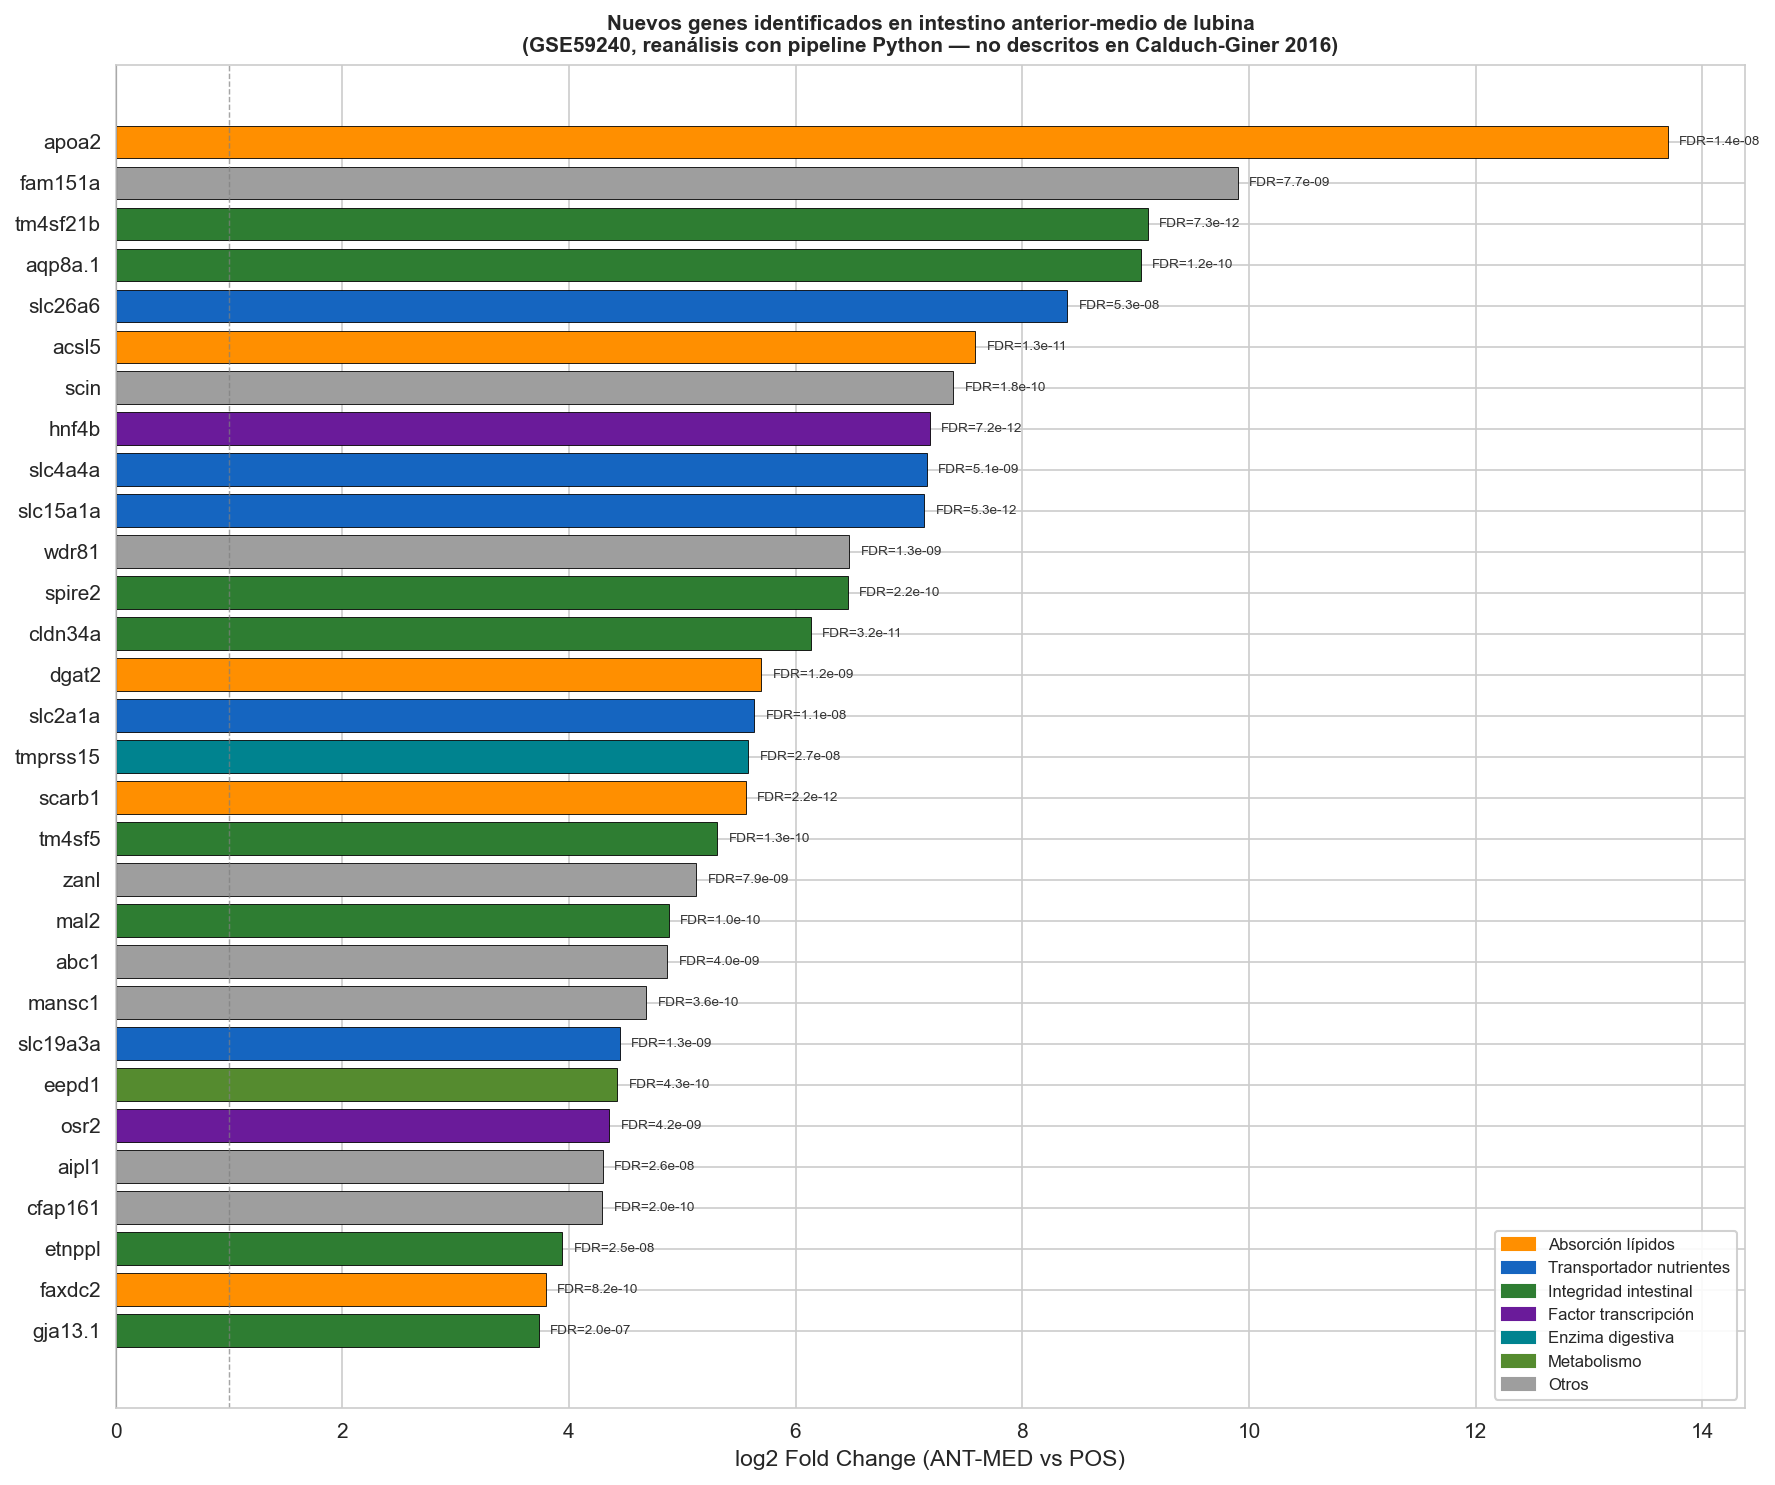

Figura guardada: Fig1_genes_nuevos_lubina.png


In [35]:
# Filtrar solo genes nuevos (sin LOC IDs)
df_nuevos = resultado_clean[
    resultado_clean['gene_name'].isin(genes_nuevos_limpios)
].copy()

# Seleccionar top 30 por FC
top30 = df_nuevos.nlargest(30, 'FC_ANT_vs_POS').sort_values('FC_ANT_vs_POS')

# Colores según categoría
colores = [COLORES_CAT.get(c, '#9E9E9E') for c in top30['categoria']]

# Figura
fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(
    top30['gene_name'],
    top30['FC_ANT_vs_POS'],
    color=colores,
    edgecolor='black',
    linewidth=0.4
)

# Añadir FDR como texto en cada barra
for i, (_, row) in enumerate(top30.iterrows()):
    fdr_txt = f"FDR={row['padj']:.1e}"
    ax.text(
        row['FC_ANT_vs_POS'] + 0.1, i,
        fdr_txt, va='center', fontsize=6.5, color='#333333'
    )

# Líneas de referencia
ax.axvline(0, color='black', linewidth=1)
ax.axvline(1, color='gray', linestyle='--', linewidth=0.7, alpha=0.7,
           label='|log2FC| = 1')

ax.set_xlabel('log2 Fold Change (ANT-MED vs POS)', fontsize=11)
ax.set_title(
    'Nuevos genes identificados en intestino anterior-medio de lubina\n'
    '(GSE59240, reanálisis con pipeline Python — no descritos en Calduch-Giner 2016)',
    fontsize=10, fontweight='bold'
)

# Leyenda de categorías
legend_elements = [
    mpatches.Patch(color=c, label=cat)
    for cat, c in COLORES_CAT.items()
    if cat in top30['categoria'].values
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('Fig1_genes_nuevos_lubina.png', bbox_inches='tight', dpi=200)
plt.show()
print('Figura guardada: Fig1_genes_nuevos_lubina.png')

In [36]:
# Construir tabla final
tabla = df_nuevos[[
    'gene_name', 'descripcion', 'FC_ANT_vs_POS', 'padj', 'categoria'
]].copy()

tabla.columns = ['Gen', 'Descripción', 'log2FC (ANT/POS)', 'FDR', 'Categoría']
tabla['log2FC (ANT/POS)'] = tabla['log2FC (ANT/POS)'].round(2)
tabla['FDR'] = tabla['FDR'].apply(lambda x: f'{x:.2e}')
tabla = tabla.sort_values(['Categoría', 'FDR']).reset_index(drop=True)

# Guardar CSV
tabla.to_csv('tabla_genes_nuevos_lubina.csv', index=False)
print(f'Tabla guardada: tabla_genes_nuevos_lubina.csv')
print(f'   Total genes nuevos: {len(tabla)}')
print(f'\nDistribución por categoría:')
print(tabla['Categoría'].value_counts().to_string())
print(f'\nTabla completa:')
tabla

Tabla guardada: tabla_genes_nuevos_lubina.csv
   Total genes nuevos: 58

Distribución por categoría:
Categoría
Otros                       16
Absorción lípidos           13
Integridad intestinal       12
Transportador nutrientes     6
Metabolismo                  4
Enzima digestiva             3
Factor transcripción         3
Inmunidad                    1

Tabla completa:


,Gen,Descripción,log2FC (ANT/POS),FDR,Categoría
0,adipor2,adiponectin receptor 2,2.94,1.18e-10,Absorción lípidos
1,dgat2,diacylglycerol O-acyltransferase 2,5.70,1.24e-09,Absorción lípidos
2,acsl5,acyl-CoA synthetase long chain family member 5,7.59,1.31e-11,Absorción lípidos
3,apoa2,apolipoprotein A-II,13.70,1.37e-08,Absorción lípidos
4,mogat2,monoacylglycerol O-acyltransferase 2,1.62,1.49e-07,Absorción lípidos
5,scarb1,"scavenger receptor class B, member 1",5.56,2.20e-12,Absorción lípidos
6,pcyt1bb,"phosphate cytidylyltransferase 1B, choline b",3.54,3.88e-10,Absorción lípidos
7,cideb,cell death inducing DFFA like effector b,2.25,7.30e-08,Absorción lípidos
8,scp2a,sterol carrier protein 2a,2.41,7.78e-10,Absorción lípidos
9,bco1,beta-carotene oxygenase 1,3.23,8.00e-08,Absorción lípidos


## 3.7 Tabla completa de genes nuevos

Exporta la tabla con todos los genes nuevos identificados,
ordenados por categoría funcional y FDR.

## Resumen del pipeline completo

| Parte | Proceso | Output |
|-------|---------|--------|
| 1 | SOFT → patrones → FASTA | `DEGs_lubina_anotados.csv`, `BLAST_lubina_AltoANT-MED.fasta` |
| **BLAST externo** | NCBI BLAST  | `HitTable.csv` |
| 2 | HitTable → accessions | `DEGs_lubina_con_accession.csv`, `accessions_lubina.txt` |
| **Batch Entrez externo** | NCBI Batch Entrez  | `nuccore_result.txt` |
| 3 | Nombres → genes nuevos | `tabla_genes_nuevos_lubina.csv`, figuras |

In [ ]:
import sys
print(f'Python: {sys.version}')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'matplotlib: {plt.matplotlib.__version__}')
print(f'seaborn: {sns.__version__}')